# **Eksperimen SML - Ahmad Asyhadi**

Notebook ini dibuat menggunakan **Template Eksperimen MSML** dan memuat seluruh tahapan eksperimen secara manual, mulai dari perkenalan dataset, import library, data loading, Exploratory Data Analysis (EDA), hingga preprocessing dataset.


# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Breast Cancer Wisconsin Dataset**. Dataset ini digunakan untuk klasifikasi diagnosis kanker payudara berdasarkan karakteristik sel hasil pemeriksaan.

Tujuan eksperimen ini adalah membangun dataset hasil preprocessing yang siap digunakan untuk pelatihan model machine learning.

**Informasi dataset:**

- Nama dataset: Breast Cancer Wisconsin Dataset
- Jenis masalah: Classification
- Target: `diagnosis`
- Jumlah fitur utama: 30 fitur numerik
- Label target:
  - `M` = Malignant
  - `B` = Benign

Pada tahap preprocessing, label target akan dikonversi menjadi bentuk numerik:

- `M` menjadi `0`
- `B` menjadi `1`

Dataset mentah disimpan dalam folder:

```text
../namadataset_raw/breast_cancer_raw.csv
```

Dataset hasil preprocessing akan disimpan dalam folder:

```text
namadataset_preprocessing/breast_cancer_preprocessing.csv
```


# **2. Import Library**


Pada tahap ini, beberapa library Python yang diperlukan akan diimpor. Library digunakan untuk membaca data, melakukan eksplorasi data, visualisasi, preprocessing, dan pembagian dataset.


In [207]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# **3. Memuat Dataset**


Pada tahap ini dataset mentah dimuat menggunakan `pandas`. Path dibuat fleksibel agar notebook bisa dijalankan dari folder `preprocessing` maupun dari root project.


In [208]:
# Path dataset mentah
# Dibuat fleksibel agar notebook bisa dijalankan dari root project maupun dari folder Eksperimen_SML_AhmadAsyhadi.
possible_paths = [
    Path("namadataset_raw/breast_cancer_raw.csv"),
    Path("../namadataset_raw/breast_cancer_raw.csv"),
    Path("Eksperimen_SML_AhmadAsyhadi/namadataset_raw/breast_cancer_raw.csv"),
    Path("breast_cancer_raw.csv")
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "File breast_cancer_raw.csv tidak ditemukan. "
        "Pastikan dataset berada di folder namadataset_raw/breast_cancer_raw.csv."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset berhasil dimuat dari: {DATA_PATH}")
df.head()


Dataset berhasil dimuat dari: ..\namadataset_raw\breast_cancer_raw.csv


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [209]:
# Melihat ukuran dataset
print("Jumlah baris dan kolom:", df.shape)


Jumlah baris dan kolom: (569, 31)


In [210]:
# Melihat nama kolom dataset
df.columns.tolist()


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'diagnosis']

# **4. Exploratory Data Analysis (EDA)**

Tahap EDA dilakukan untuk memahami struktur dataset, tipe data, data kosong, distribusi target, serta hubungan antar fitur.


## 4.1 Informasi Struktur Dataset


In [211]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 4.2 Statistik Deskriptif


In [212]:
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 4.3 Pemeriksaan Missing Value


In [213]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [214]:
print("Total missing value:", df.isnull().sum().sum())


Total missing value: 0


## 4.4 Pemeriksaan Data Duplikat


In [215]:
duplicate_count = df.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)


Jumlah data duplikat: 0


## 4.5 Distribusi Target


In [216]:
df["diagnosis"].value_counts()


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

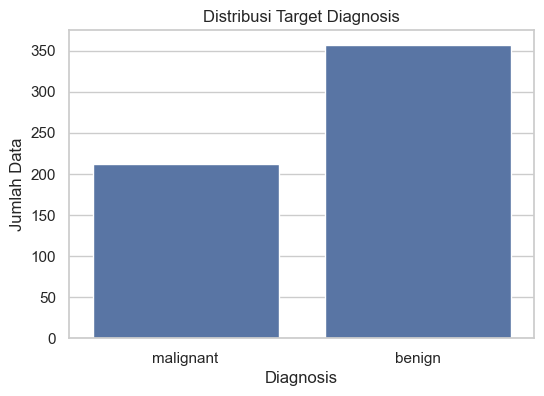

In [217]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribusi Target Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah Data")
plt.show()


## 4.6 Korelasi Fitur Numerik


d:\5. Belajar\20. Aplikasi ML\SMSML_AhmadAsyhadi\venv\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
d:\5. Belajar\20. Aplikasi ML\SMSML_AhmadAsyhadi\venv\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


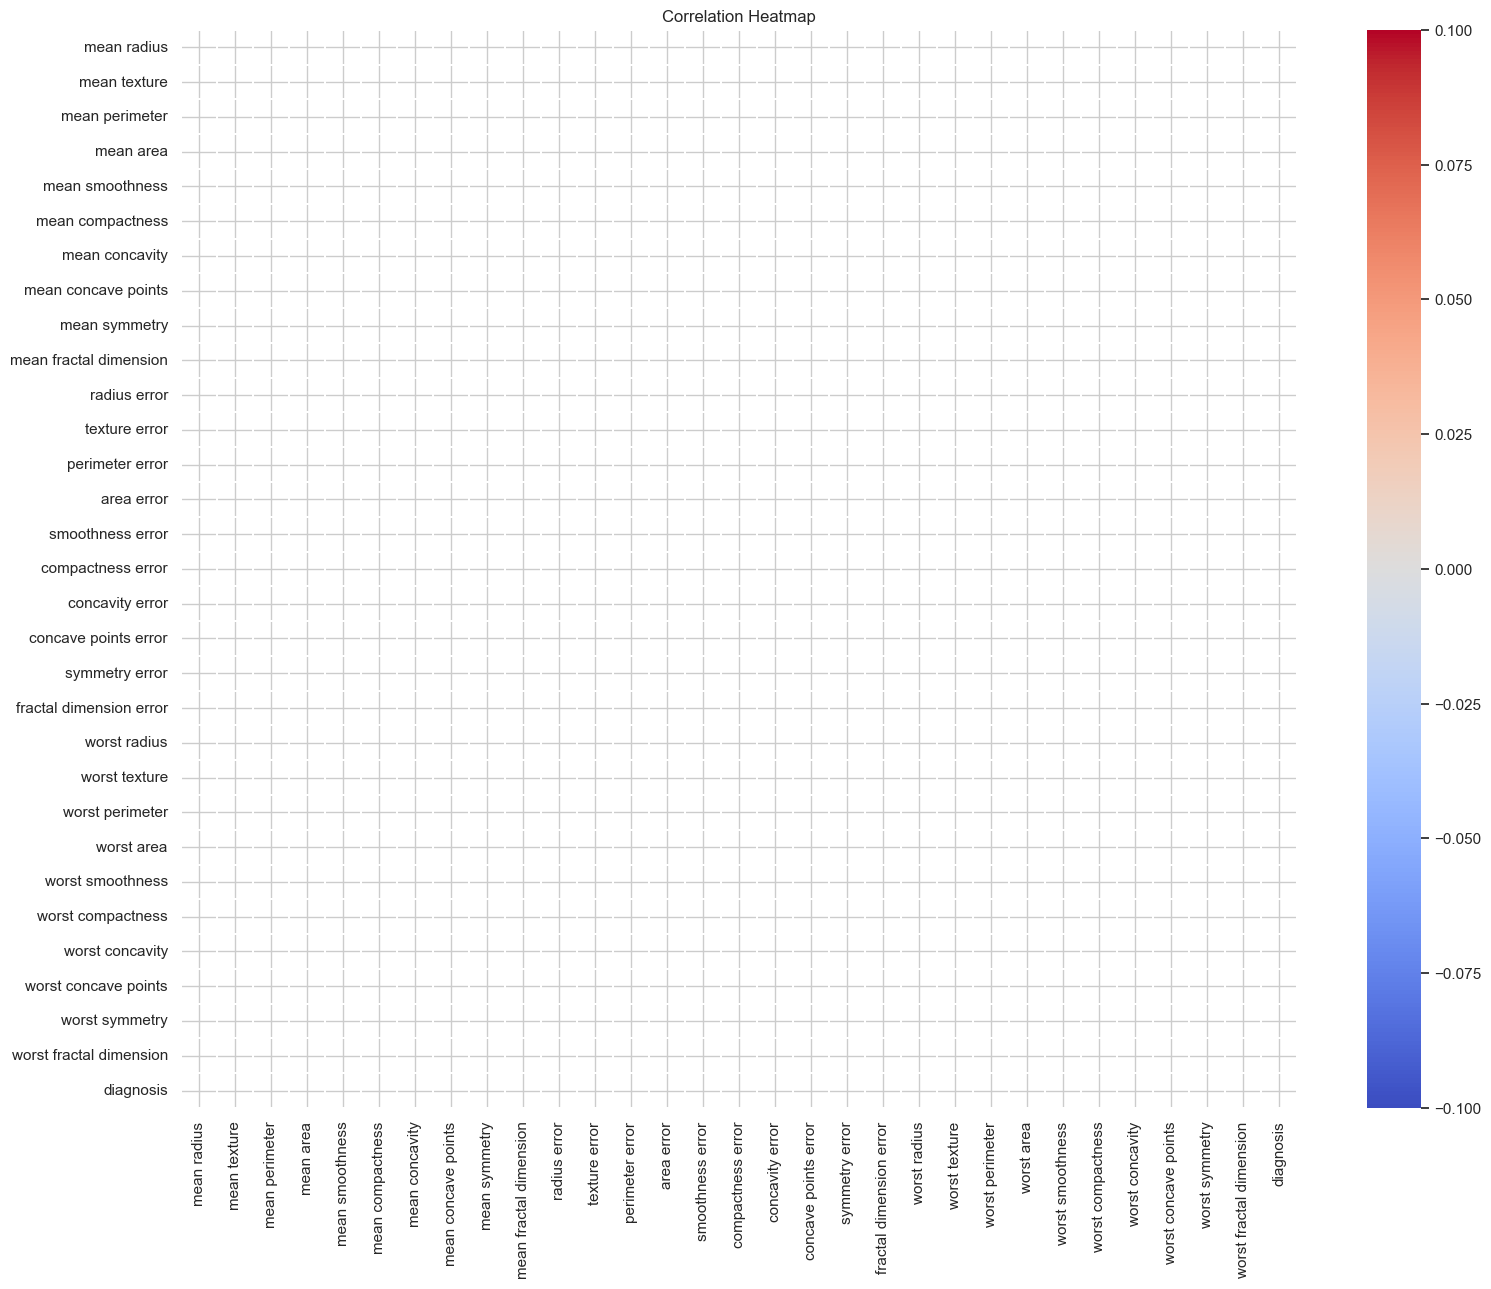

In [218]:
# Menghapus kolom id jika tersedia agar tidak mengganggu analisis korelasi
eda_df = df.copy()

for col in ["id", "Unnamed: 32"]:
    if col in eda_df.columns:
        eda_df = eda_df.drop(columns=[col])

# Encoding sementara target untuk korelasi.
# Dibuat aman: jika diagnosis sudah numerik 0/1, tidak akan di-map ulang menjadi NaN.
if eda_df["diagnosis"].dtype == "object":
    eda_df["diagnosis"] = eda_df["diagnosis"].map({"M": 0, "B": 1})

eda_df["diagnosis"] = pd.to_numeric(eda_df["diagnosis"], errors="coerce")
eda_df = eda_df.dropna(subset=["diagnosis"])

plt.figure(figsize=(18, 14))
sns.heatmap(eda_df.corr(numeric_only=True), cmap="coolwarm", linewidths=0.2)
plt.title("Correlation Heatmap")
plt.show()


## 4.7 Distribusi Beberapa Fitur Penting


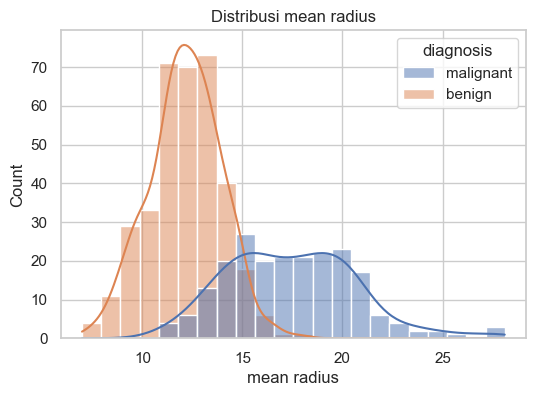

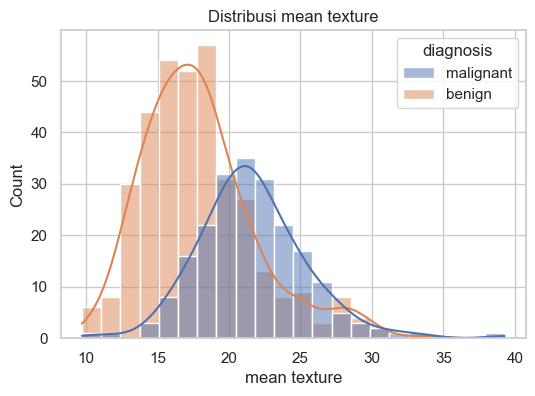

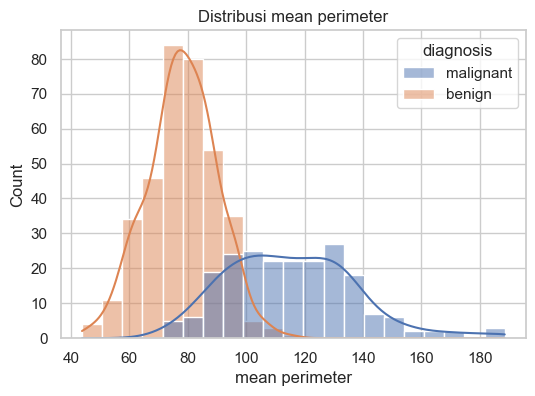

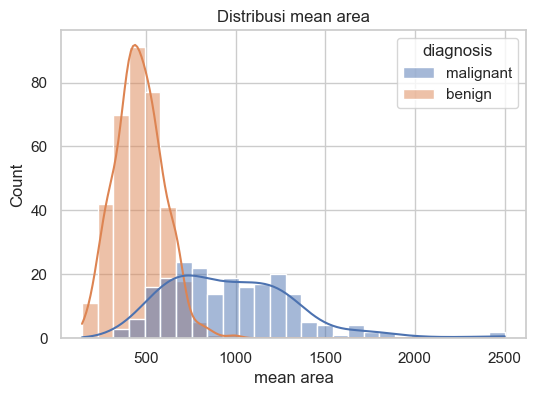

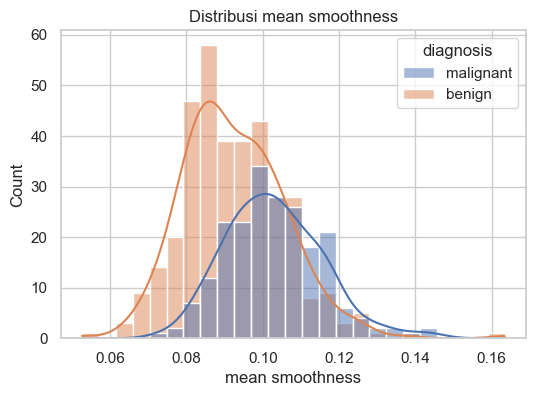

In [219]:
important_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

for feature in important_features:
    if feature in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(data=df, x=feature, hue="diagnosis", kde=True)
        plt.title(f"Distribusi {feature}")
        plt.show()


# **5. Data Preprocessing**

Tahap preprocessing dilakukan secara manual di notebook sesuai template eksperimen. Proses preprocessing meliputi:

1. Menghapus kolom yang tidak diperlukan.
2. Menghapus data duplikat jika ada.
3. Mengonversi target kategorikal menjadi numerik.
4. Memisahkan fitur dan target.
5. Melakukan train-test split.
6. Melakukan feature scaling.
7. Menyimpan dataset hasil preprocessing.


## 5.1 Menyalin Dataset


In [220]:
df_clean = df.copy()
df_clean.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 5.2 Menghapus Kolom Tidak Diperlukan


In [221]:
# Kolom id tidak digunakan untuk pemodelan karena hanya berfungsi sebagai identifier
if "id" in df_clean.columns:
    df_clean = df_clean.drop(columns=["id"])

# Beberapa dataset breast cancer memiliki kolom kosong bernama Unnamed: 32
if "Unnamed: 32" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 32"])

df_clean.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 5.3 Menghapus Data Duplikat


In [222]:
before_drop = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_drop = df_clean.shape[0]

print("Jumlah data sebelum drop duplicate:", before_drop)
print("Jumlah data setelah drop duplicate:", after_drop)


Jumlah data sebelum drop duplicate: 569
Jumlah data setelah drop duplicate: 569


## 5.4 Encoding Target


In [223]:
# Encoding target diagnosis
# M = Malignant -> 0
# B = Benign -> 1
# Jika diagnosis sudah numerik, cell ini tetap aman dijalankan berulang.

print("Nilai diagnosis sebelum encoding:")
print(df_clean["diagnosis"].value_counts(dropna=False))

if df_clean["diagnosis"].dtype == "object":
    df_clean["diagnosis"] = df_clean["diagnosis"].map({"M": 0, "B": 1})

df_clean["diagnosis"] = pd.to_numeric(df_clean["diagnosis"], errors="coerce")

# Hapus baris yang targetnya kosong
df_clean = df_clean.dropna(subset=["diagnosis"])
df_clean["diagnosis"] = df_clean["diagnosis"].astype(int)

print("\nNilai diagnosis setelah encoding:")
print(df_clean["diagnosis"].value_counts(dropna=False))
print("\nJumlah NaN pada diagnosis:", df_clean["diagnosis"].isna().sum())


Nilai diagnosis sebelum encoding:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Nilai diagnosis setelah encoding:
Series([], Name: count, dtype: int64)

Jumlah NaN pada diagnosis: 0


## 5.5 Memisahkan Fitur dan Target


In [224]:
# Memisahkan fitur dan target
X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

# Pastikan semua fitur numerik
X = X.apply(pd.to_numeric, errors="coerce")

# Jika ada missing value pada fitur, isi dengan median tiap kolom
X = X.fillna(X.median(numeric_only=True))

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("Jumlah NaN pada y:", y.isna().sum())
print("\nDistribusi target:")
print(y.value_counts(dropna=False))


Jumlah fitur: 30
Jumlah data: 0
Jumlah NaN pada y: 0

Distribusi target:
Series([], Name: count, dtype: int64)


## 5.6 Train-Test Split


In [225]:
from pathlib import Path

# Reload dataset asli agar encoding tidak dobel
raw_path = Path("../namadataset_raw/breast_cancer_raw.csv")

df = pd.read_csv(raw_path)

# Hapus kolom yang tidak diperlukan jika ada
drop_columns = ["id", "Unnamed: 32"]
df = df.drop(columns=[col for col in drop_columns if col in df.columns])

print("Cek target sebelum encoding:")
print(df["diagnosis"].value_counts(dropna=False))

# Encoding target
df["diagnosis"] = df["diagnosis"].replace({
    "B": 0,
    "M": 1,
    "benign": 0,
    "malignant": 1
})

df["diagnosis"] = pd.to_numeric(df["diagnosis"], errors="coerce")
df = df.dropna(subset=["diagnosis"]).copy()
df["diagnosis"] = df["diagnosis"].astype(int)

print("Distribusi diagnosis setelah encoding:")
print(df["diagnosis"].value_counts(dropna=False))

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Jumlah NaN pada y:", y.isna().sum())
print("Distribusi y:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Cek target sebelum encoding:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64
Distribusi diagnosis setelah encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64
Jumlah NaN pada y: 0
Distribusi y:
diagnosis
0    357
1    212
Name: count, dtype: int64
X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25316\3917853814.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diagnosis"] = df["diagnosis"].replace({


## 5.7 Feature Scaling


In [226]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (455, 30)
X_test_scaled: (114, 30)


## 5.8 Menggabungkan Dataset Hasil Preprocessing


In [227]:
train_preprocessed = X_train_scaled.copy()
train_preprocessed["diagnosis"] = y_train.reset_index(drop=True)

test_preprocessed = X_test_scaled.copy()
test_preprocessed["diagnosis"] = y_test.reset_index(drop=True)

preprocessed_df = pd.concat(
    [train_preprocessed, test_preprocessed],
    axis=0,
    ignore_index=True
)

preprocessed_df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,-0.109318,-0.055976,-0.210096,-0.015913,-1.005184,-0.911942,-0.662816,-0.652561,-0.701889,-0.275394,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837,1
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,-0.604378,-1.001046,-0.585429,-0.493454,0.403212,-0.768173,-0.479187,0.114508,-0.142951,-0.577398,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402,0
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,0.303980,1.051501,-0.169545,-0.000809,-0.310104,1.106330,0.622585,0.273685,0.754483,1.508105,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016,0
3,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,-0.545730,-0.621677,0.261427,-0.353585,0.024460,2.090728,1.490561,1.695127,-0.654909,0.767548,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848,1
4,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,1.523863,1.143941,1.282748,1.081313,1.351845,0.107731,0.592927,1.180988,0.301550,0.171527,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249,1


In [228]:
preprocessed_df.shape


(569, 31)

## 5.9 Menyimpan Dataset Hasil Preprocessing


In [229]:
# Membuat folder output jika belum tersedia.
# Jika notebook dijalankan dari folder Eksperimen_SML_AhmadAsyhadi, output akan masuk ke:
# preprocessing/namadataset_preprocessing/breast_cancer_preprocessing.csv

root_output_dir = Path("preprocessing") / "namadataset_preprocessing"
alt_output_dir = Path("namadataset_preprocessing")

if Path("namadataset_raw").exists():
    output_dir = root_output_dir
else:
    output_dir = alt_output_dir

output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "breast_cancer_preprocessing.csv"
preprocessed_df.to_csv(output_path, index=False)

print(f"Dataset hasil preprocessing berhasil disimpan ke: {output_path}")


Dataset hasil preprocessing berhasil disimpan ke: namadataset_preprocessing\breast_cancer_preprocessing.csv


# **6. Kesimpulan**

Eksperimen dataset telah dilakukan menggunakan Template Eksperimen MSML. Seluruh tahapan utama telah dilakukan secara manual dalam notebook, yaitu:

- Memuat dataset mentah.
- Melakukan EDA.
- Membersihkan data.
- Melakukan encoding target.
- Melakukan train-test split.
- Melakukan scaling fitur numerik.
- Menyimpan dataset hasil preprocessing.

Dataset hasil preprocessing siap digunakan pada tahap pembangunan model machine learning dan workflow otomatis.
